In [12]:
import pandas as pd 
import numpy as np
import torch
from collections import OrderedDict
from typing import Dict, List, Tuple

In [13]:
# =============================================================================
# Konfigurasi path dataset
# =============================================================================
BASE_DIR = r"C:\Users\s2\Documents\Federated\dataset"

PATHS = {
    "drebin": f"{BASE_DIR}/drebin-215-dataset-5560malware-9476-benign.csv",
    "kronodroid": f"{BASE_DIR}/kronodroid.csv",
    "malgenome": f"{BASE_DIR}/malgenome.csv",
    "tuandromd": f"{BASE_DIR}/TUANDROMD 2.csv",
}


# %%
# =============================================================================
# Fungsi bantu
# =============================================================================
def load_raw(path: str) -> pd.DataFrame:
    """Baca CSV dan buang kolom index bawaan ('Unnamed: 0') kalau ada."""
    data = pd.read_csv(path)
    if "Unnamed: 0" in data.columns:
        data = data.drop(columns=["Unnamed: 0"])
    return data


def encode_label(data: pd.DataFrame, label_col: str, mapping: Dict) -> pd.DataFrame:
    """Encode kolom label sesuai mapping, mis. {'B': 0, 'S': 1}."""
    data = data.copy()
    data[label_col] = data[label_col].replace(mapping)
    return data


def to_numeric_features(data: pd.DataFrame, label_col: str) -> pd.DataFrame:
    """Paksa semua kolom selain label jadi numerik; nilai gagal -> NaN."""
    data = data.copy()
    feature_columns = [c for c in data.columns if c != label_col]
    data[feature_columns] = data[feature_columns].apply(pd.to_numeric, errors="coerce")
    return data


def report(name: str, X: np.ndarray, y: np.ndarray) -> None:
    print(f"[{name}]")
    print("  Ukuran X       :", X.shape)
    print("  Ukuran y       :", y.shape)
    print("  Distribusi kelas:", np.bincount(y))
    print()


def split_features_labels(
    data: pd.DataFrame, label_col: str
) -> Tuple[np.ndarray, np.ndarray]:
    X = data.drop(columns=[label_col]).values.astype(np.float32)
    y = data[label_col].astype(int).values
    return X, y


In [14]:
from dataset import split_and_prepare_data
# =============================================================================
# 1. Dataset Drebin
# =============================================================================
LABEL_COLUMN = "class"  # sesuaikan dengan nama kolom label sebenarnya di file Drebin
SPECIAL_COLUMN = "TelephonyManager.getSimCountryIso"
 
data = load_raw(PATHS["drebin"])
 
if SPECIAL_COLUMN in data.columns:
    data[SPECIAL_COLUMN] = data[SPECIAL_COLUMN].replace("?", np.nan)
    data[SPECIAL_COLUMN] = pd.to_numeric(data[SPECIAL_COLUMN], errors="coerce")
 
if LABEL_COLUMN not in data.columns:
    raise KeyError(f"Kolom '{LABEL_COLUMN}' tidak ditemukan. Kolom tersedia: {list(data.columns)}")
 
data = encode_label(data, LABEL_COLUMN, {"B": 0, "S": 1})
data = to_numeric_features(data, LABEL_COLUMN)
data = data.dropna().reset_index(drop=True)
 
X_drebin, y_drebin = split_features_labels(data, LABEL_COLUMN)
N_CLASSES = len(np.unique(y_drebin))
N_FEATURES = X_drebin.shape[1]
 
report("Drebin", X_drebin, y_drebin)
print("Jumlah kelas:", N_CLASSES)
 
drebin_split = split_and_prepare_data(X_drebin, y_drebin)
 
 
# %%
# =============================================================================
# 2. Dataset KronoDroid
# =============================================================================
LABEL_COL_KRONO = "Malware"
 
data = load_raw(PATHS["kronodroid"])
print("Ukuran data awal:", data.shape)
print("\nMissing value sebelum drop:", data.isna().sum().sum())
 
data = data.dropna().reset_index(drop=True)
print("Missing value setelah drop:", data.isna().sum().sum())
 
print("\nNilai unik Malware:", data[LABEL_COL_KRONO].unique())
print("Distribusi kelas Malware:\n", data[LABEL_COL_KRONO].value_counts())
 
data = to_numeric_features(data, LABEL_COL_KRONO)
data = data.dropna().reset_index(drop=True)
 
X_krono, y_krono = split_features_labels(data, LABEL_COL_KRONO)
target_names_krono = ["goodware", "malware"]
 
report("KronoDroid", X_krono, y_krono)
print("Jumlah fitur:", X_krono.shape[1])
 
krono_split = split_and_prepare_data(X_krono, y_krono)
 
 
# %%
# =============================================================================
# 3. Dataset MalGenome
# =============================================================================
LABEL_COL_MALGENOME = "class"
 
data = load_raw(PATHS["malgenome"])
print("Missing value per kolom:\n", data.isna().sum())
 
data = encode_label(data, LABEL_COL_MALGENOME, {"B": 0, "S": 1})
data = to_numeric_features(data, LABEL_COL_MALGENOME)
data = data.dropna().reset_index(drop=True)
 
X_malgenome, y_malgenome = split_features_labels(data, LABEL_COL_MALGENOME)
target_names_malgenome = ["benign", "malware"]
 
report("MalGenome", X_malgenome, y_malgenome)
 
malgenome_split = split_and_prepare_data(X_malgenome, y_malgenome)

# =============================================================================
# 4. Dataset TUANDROMD
# =============================================================================
LABEL_COL_TUANDROMD = "Label"
 
data = load_raw(PATHS["tuandromd"])
print("Missing value sebelum drop:", data.isna().sum().sum())
 
data = data.dropna().reset_index(drop=True)
print("Missing value setelah drop:", data.isna().sum().sum())
 
print("Nilai unik Label:", data[LABEL_COL_TUANDROMD].unique())
 
data = encode_label(data, LABEL_COL_TUANDROMD, {"goodware": 0, "malware": 1})
data = to_numeric_features(data, LABEL_COL_TUANDROMD)
data = data.dropna().reset_index(drop=True)
 
X_tuandromd, y_tuandromd = split_features_labels(data, LABEL_COL_TUANDROMD)
target_names_tuandromd = ["goodware", "malware"]
 
report("TUANDROMD", X_tuandromd, y_tuandromd)
 
tuandromd_split = split_and_prepare_data(X_tuandromd, y_tuandromd)

C:\Users\s2\AppData\Local\Temp\ipykernel_27384\1764348774.py:20: DtypeWarning: Columns (92: TelephonyManager.getSimCountryIso) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)


[Drebin]
  Ukuran X       : (15031, 215)
  Ukuran y       : (15031,)
  Distribusi kelas: [9476 5555]

Jumlah kelas: 2
Train: torch.Size([10521, 215]) | Val: torch.Size([2255, 215]) | Test: torch.Size([2255, 215])
Ukuran data awal: (78137, 463)

Missing value sebelum drop: 0
Missing value setelah drop: 0

Nilai unik Malware: [1 0]
Distribusi kelas Malware:
 Malware
1    41382
0    36755
Name: count, dtype: int64
[KronoDroid]
  Ukuran X       : (78137, 462)
  Ukuran y       : (78137,)
  Distribusi kelas: [36755 41382]

Jumlah fitur: 462
Train: torch.Size([54695, 462]) | Val: torch.Size([11721, 462]) | Test: torch.Size([11721, 462])
Missing value per kolom:
 transact                                 0
bindService                              0
onServiceConnected                       0
ServiceConnection                        0
android.os.Binder                        0
                                        ..
GLOBAL_SEARCH                            0
GET_PACKAGE_SIZE                   

In [15]:
# Ringkasan semua split
# =============================================================================
all_splits = {
    "drebin": drebin_split,
    "kronodroid": krono_split,
    "malgenome": malgenome_split,
    "tuandromd": tuandromd_split,
}
 
for name, split in all_splits.items():
    print(f"\n[{name}]")
    print("  X_train:", split["X_train_t"].shape)
    print("  X_val  :", split["X_val_t"].shape)
    print("  X_test :", split["X_test_t"].shape)


[drebin]
  X_train: torch.Size([10521, 215])
  X_val  : torch.Size([2255, 215])
  X_test : torch.Size([2255, 215])

[kronodroid]
  X_train: torch.Size([54695, 462])
  X_val  : torch.Size([11721, 462])
  X_test : torch.Size([11721, 462])

[malgenome]
  X_train: torch.Size([2659, 215])
  X_val  : torch.Size([570, 215])
  X_test : torch.Size([570, 215])

[tuandromd]
  X_train: torch.Size([3124, 241])
  X_val  : torch.Size([670, 241])
  X_test : torch.Size([670, 241])


In [16]:
# %% [Cell 2] -- siapkan fed_data (seperti sebelumnya)
from fl_running2 import (
    run_federated, print_theta_report, theta_report_to_rows, approx_theta_gap,
    print_theta_before_after_report,   # NEW
)
import pandas as pd
import matplotlib.pyplot as plt

n_features_map = {
    "drebin":     X_drebin.shape[1],
    "kronodroid": X_krono.shape[1],
    "malgenome":  X_malgenome.shape[1],
    "tuandromd":  X_tuandromd.shape[1],
}

fed_data = {}
for name, split in all_splits.items():
    fed_data[name] = {
        "X_train": split["X_train_t"], "y_train": split["y_train_t"],
        "X_val":   split["X_val_t"],   "y_val":   split["y_val_t"],
        "X_test":  split["X_test_t"],  "y_test":  split["y_test_t"],
        "n_features": n_features_map[name],
    }

for name, c in fed_data.items():
    print(name, "n_features =", c["n_features"], "train", tuple(c["X_train"].shape))

drebin n_features = 215 train (10521, 215)
kronodroid n_features = 462 train (54695, 462)
malgenome n_features = 215 train (2659, 215)
tuandromd n_features = 241 train (3124, 241)


In [17]:
# %% [Cell 3] -- jalankan training (SEKALI SAJA)
COMMON = dict(
    common_dim=128,
    n_classes=2,
    num_rounds=20,
    local_epochs=2,
)

history = run_federated(fed_data, name="FedPer", **COMMON)

INFO :      Starting Flower ServerApp, config: num_rounds=20, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Evaluating initial global parameters
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)
INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (1, 0.28465646132826805, {'accuracy': 0.8462148918846965, 'precision': 0.7706412591269396, 'recall': 0.9867584332893435, 'f1': 0.8468701402161055}, 12.895455899997614)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[FedPer] round 01 | loss=0.2847 acc=0.8462 f1=0.8469 | comm=0.315MB (cum 0.315MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (2, 0.09342664759606123, {'accuracy': 0.9721916897636491, 'precision': 0.9574299415911596, 'recall': 0.9812264968031523, 'f1': 0.9685835745644717}, 16.93911279999884)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[FedPer] round 02 | loss=0.0934 acc=0.9722 f1=0.9686 | comm=0.315MB (cum 0.631MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (3, 0.08363610785454512, {'accuracy': 0.9728308865500033, 'precision': 0.9581255928859509, 'recall': 0.9806012871494754, 'f1': 0.9685031583767952}, 20.99682900001062)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 4]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


...

[FedPer] round 18 | loss=0.1583 acc=0.9803 f1=0.9774 | comm=0.315MB (cum 5.678MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (19, 0.24836271069943905, {'accuracy': 0.9799822403048357, 'precision': 0.9740603739405471, 'recall': 0.9833978794326136, 'f1': 0.9785658191462872}, 85.90649769999436)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 20]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[FedPer] round 19 | loss=0.2484 acc=0.9800 f1=0.9786 | comm=0.315MB (cum 5.993MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (20, 0.22085087513551116, {'accuracy': 0.9813774307255387, 'precision': 0.9720087453435993, 'recall': 0.9858612205958588, 'f1': 0.978745815856929}, 90.95008060001419)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 20 round(s) in 90.95s
INFO :      	History (loss, centralized):
INFO :      		round 1: 0.28465646132826805
INFO :      		round 2: 0.09342664759606123
INFO :      		round 3: 0.08363610785454512
INFO :      		round 4: 0.07759385136887431
INFO :      		round 5: 0.06584175303578377
INFO :      		round 6: 0.07037711702287197
INFO :      		round 7: 0.08023379882797599
INFO :      		round 8: 0.08130181208252907
INFO :      		round 9: 0.06556084984913468
INFO :      		round 10: 0.07845817692577839
INFO :      		round 11: 0.09237355086952448
INFO :      		round 12: 0.09934859303757548
INFO :      		round 13: 0.1492

[FedPer] round 20 | loss=0.2209 acc=0.9814 f1=0.9787 | comm=0.315MB (cum 6.309MB)
[FedPer] BANDWIDTH | theta=0.039MB up=3.15MB down=3.15MB total=6.31MB (~0.32MB/ronde)


In [18]:
# %%
# Laporan teks: theta SEBELUM vs SESUDAH training lokal, per client per ronde
print_theta_before_after_report(history["theta_log_before"], history["theta_log"])


=== THETA SEBELUM vs SESUDAH TRAINING LOKAL (per client, per round) ===

[tuandromd]
  round 01 | norm_recv=nan -> norm_after=6.4222 (Δ=6.4222)
  round 02 | norm_recv=nan -> norm_after=7.3769 (Δ=7.3769)
  round 03 | norm_recv=nan -> norm_after=8.3720 (Δ=8.3720)
  round 04 | norm_recv=nan -> norm_after=9.1807 (Δ=9.1807)
  round 05 | norm_recv=nan -> norm_after=9.9792 (Δ=9.9792)
  round 06 | norm_recv=nan -> norm_after=10.7620 (Δ=10.7620)
  round 07 | norm_recv=nan -> norm_after=11.5696 (Δ=11.5696)
  round 08 | norm_recv=nan -> norm_after=12.3436 (Δ=12.3436)
  round 09 | norm_recv=nan -> norm_after=13.0835 (Δ=13.0835)
  round 10 | norm_recv=nan -> norm_after=13.6710 (Δ=13.6710)
  round 11 | norm_recv=nan -> norm_after=14.3386 (Δ=14.3386)
  round 12 | norm_recv=nan -> norm_after=14.9250 (Δ=14.9250)
  round 13 | norm_recv=nan -> norm_after=15.3237 (Δ=15.3237)
  round 14 | norm_recv=nan -> norm_after=15.9038 (Δ=15.9038)
  round 15 | norm_recv=nan -> norm_after=16.4928 (Δ=16.4928)
  round 1

In [19]:
print_theta_report(history["theta_log"], history["global_theta_per_round"])


=== LAPORAN THETA PER CLIENT ===

[tuandromd]
  round 01 | n_params=10336 mean=0.01084 std=0.06223 norm=6.4222 min=-0.1638 max=0.1769
  round 02 | n_params=10336 mean=0.00662 std=0.07226 norm=7.3769 min=-0.2170 max=0.2324
  round 03 | n_params=10336 mean=0.00509 std=0.08219 norm=8.3720 min=-0.3009 max=0.3010
  round 04 | n_params=10336 mean=0.00418 std=0.09021 norm=9.1807 min=-0.3358 max=0.3184
  round 05 | n_params=10336 mean=0.00352 std=0.09809 norm=9.9792 min=-0.4360 max=0.3508
  round 06 | n_params=10336 mean=0.00128 std=0.10585 norm=10.7620 min=-0.4828 max=0.4164
  round 07 | n_params=10336 mean=0.00061 std=0.11380 norm=11.5696 min=-0.5096 max=0.5170
  round 08 | n_params=10336 mean=0.00095 std=0.12141 norm=12.3436 min=-0.4975 max=0.6073
  round 09 | n_params=10336 mean=0.00205 std=0.12867 norm=13.0835 min=-0.5837 max=0.6668
  round 10 | n_params=10336 mean=-0.00003 std=0.13447 norm=13.6710 min=-0.6169 max=0.6898
  round 11 | n_params=10336 mean=0.00170 std=0.14103 norm=14.3386 m


=== LAPORAN THETA PER CLIENT ===

[tuandromd]
  round 01 | n_params=10336 mean=0.01084 std=0.06223 norm=6.4222 min=-0.1638 max=0.1769
  round 02 | n_params=10336 mean=0.00662 std=0.07226 norm=7.3769 min=-0.2170 max=0.2324
  round 03 | n_params=10336 mean=0.00509 std=0.08219 norm=8.3720 min=-0.3009 max=0.3010
  round 04 | n_params=10336 mean=0.00418 std=0.09021 norm=9.1807 min=-0.3358 max=0.3184
  round 05 | n_params=10336 mean=0.00352 std=0.09809 norm=9.9792 min=-0.4360 max=0.3508
  round 06 | n_params=10336 mean=0.00128 std=0.10585 norm=10.7620 min=-0.4828 max=0.4164
  round 07 | n_params=10336 mean=0.00061 std=0.11380 norm=11.5696 min=-0.5096 max=0.5170
  round 08 | n_params=10336 mean=0.00095 std=0.12141 norm=12.3436 min=-0.4975 max=0.6073
  round 09 | n_params=10336 mean=0.00205 std=0.12867 norm=13.0835 min=-0.5837 max=0.6668
  round 10 | n_params=10336 mean=-0.00003 std=0.13447 norm=13.6710 min=-0.6169 max=0.6898
  round 11 | n_params=10336 mean=0.00170 std=0.14103 norm=14.3386 m

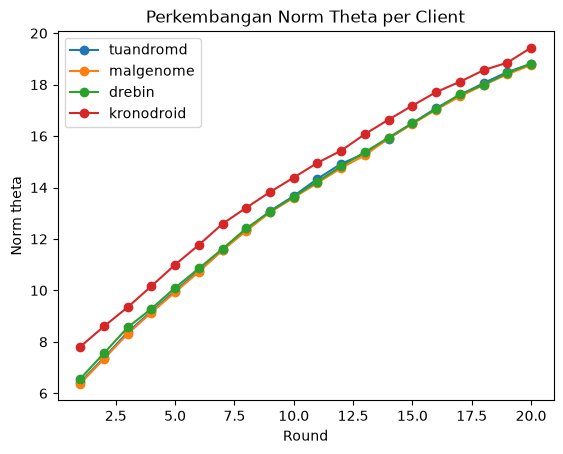

In [20]:

# %%
# Laporan teks: statistik theta tiap client tiap ronde
print_theta_report(history["theta_log"], history["global_theta_per_round"])

# %%
# Tabel (lebih enak dibaca di notebook)
df_theta = pd.DataFrame(theta_report_to_rows(history["theta_log"]))
df_theta

# %%
# Plot norm theta per client per ronde
for cname in df_theta["client"].unique():
    sub = df_theta[df_theta["client"] == cname]
    plt.plot(sub["round"], sub["norm"], marker="o", label=cname)

plt.xlabel("Round")
plt.ylabel("Norm theta")
plt.title("Perkembangan Norm Theta per Client")
plt.legend()
plt.show()

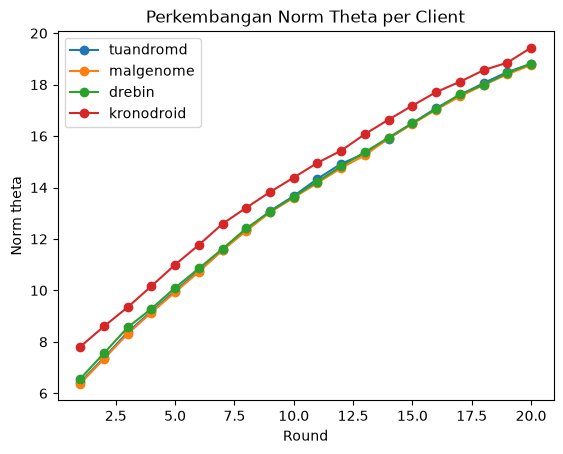

In [21]:
# %% [Cell 6] -- plot norm theta per client per ronde
for cname in df_theta["client"].unique():
    sub = df_theta[df_theta["client"] == cname]
    plt.plot(sub["round"], sub["norm"], marker="o", label=cname)

plt.xlabel("Round")
plt.ylabel("Norm theta")
plt.title("Perkembangan Norm Theta per Client")
plt.legend()
plt.show()

In [22]:
# %%
import pandas as pd

df_test = pd.DataFrame(history["test_per_client"]).T
df_test.index.name = "dataset"
df_test = df_test[["accuracy", "precision", "recall", "f1"]].round(4)
print(df_test)

            accuracy  precision  recall      f1
dataset                                        
drebin        0.9712     0.9364  0.9892  0.9621
kronodroid    0.9723     0.9802  0.9671  0.9736
malgenome     0.9825     0.9786  0.9683  0.9734
tuandromd     0.9985     0.9981  1.0000  0.9991
